In [1]:
import math
from datetime import datetime
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("torch: "+torch.__version__)

pandas: 3.0.1
numpy: 2.4.3
torch: 2.12.0


In [2]:
df = pd.read_csv('data/shot_probs_data.csv')
df.head()

,distance,angle,shot_type_numeric,shot_type,is_behind_backboard,set_name,is_made
0,0.187613,0.195018,0,JUMPER,0,train,0
1,0.029004,0.524437,1,LAYUP,0,train,0
2,0.115727,0.422763,0,JUMPER,0,train,1
3,0.256781,0.472390,0,JUMPER,0,train,1
4,0.109662,0.224862,0,JUMPER,0,train,1


In [3]:
def make_dataset(df:pd.DataFrame, set_name:str):
    dff = df.loc[df['set_name']==set_name].drop(['set_name','is_made','shot_type','shot_type_numeric'],axis=1).reset_index(drop=True)
    target = df.loc[df['set_name']==set_name]['is_made'].values
    shot_name_vals = df.loc[df['set_name']==set_name]['shot_type'].values
    return dff, target, shot_name_vals

X_train_mm, y_train, shot_train = make_dataset(df, 'train')
X_val_mm, y_val, shot_val = make_dataset(df, 'val')
X_query_mm, y_query, shot_query = make_dataset(df, 'query')
X_test_mm, y_test, shot_test = make_dataset(df, 'test')

print(X_train_mm.shape, X_val_mm.shape, X_query_mm.shape, X_test_mm.shape)

(1612163, 3) (690928, 3) (493520, 3) (493519, 3)


In [4]:
X_train_mm.head()

,distance,angle,is_behind_backboard
0,0.187613,0.195018,0
1,0.029004,0.524437,0
2,0.115727,0.422763,0
3,0.256781,0.472390,0
4,0.109662,0.224862,0


In [5]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

def score_model(model, X, y, model_name=None):
    if model_name == 'nn':
        preds = model.predict_proba(X)
    else:
        preds = model.predict_proba(X)[:,1]
    loss, auc, acc = compute_scores(y, preds)
    print(f"Log Loss: {loss:.4f}, AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    return None

In [6]:
def plot_cali_curve(truth, probs, label, color, nbins=30):
    prob_true, prob_pred = calibration_curve(truth, probs, n_bins=nbins)
    bindf = pd.DataFrame({'truth':truth, 'prob': probs})
    bin_edge = np.linspace(0, 1, nbins + 1)
    bindf['bin'] = pd.cut(bindf['prob'], bins=bin_edge)
    bin_counts = bindf.groupby('bin', observed=True).size().values
    plt.plot(prob_pred, prob_true, color=color, label=label)
    dot_sze = (bin_counts / bin_counts.max())*100
    plt.scatter(prob_pred, prob_true, color=color, s=dot_sze, label="_nolegend_")

In [7]:
def create_tensor_dataset(input, target):
    input_t = torch.tensor(np.asarray(input, dtype='float32')).to(device)
    target_t = torch.tensor(target.astype('float32')).view(-1, 1).to(device)
    dataset_t = TensorDataset(input_t, target_t)
    loader_t = DataLoader(dataset_t, batch_size=4096, shuffle=True)
    return input_t, target_t, loader_t

X_train_t, _, train_loader = create_tensor_dataset(X_train_mm, y_train)
X_val_t, y_val_t, val_loader = create_tensor_dataset(X_val_mm, y_val)

In [8]:
class MonotonicLinear(nn.Module):
    def __init__(self, in_features, out_features, mono_mask):
        super().__init__()
        self.raw_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        nn.init.kaiming_uniform_(self.raw_weight, a=math.sqrt(5))
        self.register_buffer('mono_mask', mono_mask)

    def weight(self):
        pos = F.softplus(self.raw_weight)
        w = torch.where(self.mono_mask == 1, pos, torch.where(self.mono_mask == -1, -pos, self.raw_weight))
        return w

    def forward(self, x):
        return F.linear(x, self.weight(), self.bias)


class MonotonicMLP(nn.Module):
    def __init__(self, hidden_sizes, dropout, mono_mask):
        super().__init__()
        mono_mask = torch.tensor(mono_mask, dtype=torch.float32)
        sizes = [3] + list(hidden_sizes) + [1]
        self.layers = nn.ModuleList()
        for i in range(len(sizes) - 1):
            in_f = sizes[i]
            mask = mono_mask if i == 0 else torch.ones(in_f)
            self.layers.append(MonotonicLinear(in_f, sizes[i+1], mask))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = F.relu(x)
                x = self.dropout(x)
        return x

    def predict_proba(self, X_tensor):
        self.eval()
        with torch.no_grad():
            logits = self(X_tensor)
            probs = torch.sigmoid(logits)
            return probs.cpu().numpy()

In [11]:
def train_model(model, train_loader, lr, X_val=None, y_val=None, patience=75, epochs=500, validate=True):
    criterion=nn.BCEWithLogitsLoss()
    optimizer=torch.optim.Adam(model.parameters(), lr=lr)

    train_loss_list = []
    val_loss_list = []

    best_val_loss = float('inf')
    epochs_tol = 0
    best_epoch = 0
    model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss * X_batch.size(0)
        
        epoch_loss = (running_loss/len(train_loader.dataset)).item()
        train_loss_list.append(epoch_loss)
        
        if validate:
            # validate
            model.eval()
            with torch.no_grad():
                val_preds = model(X_val)
                val_loss = criterion(val_preds, y_val).item()
                val_loss_list.append(val_loss)
                model_state = model.state_dict()
                
            if val_loss < best_val_loss:
                epochs_tol = 0
                best_val_loss = val_loss
                best_epoch = epoch + 1
                model_state = model.state_dict()
            else:
                epochs_tol += 1
            
            if epochs_tol >= patience:
                break
        else:
            best_epoch = epochs
            model_state = model.state_dict()
    if model_state is not None:
        model.load_state_dict(model_state)

    return train_loss_list, val_loss_list, model, best_epoch

In [20]:
nn_params = {
    'hidden_sizes': [(32, 16)], #[(8, 4), (16, 8), (32, 16), (32, 16, 8)],
    'dropout': [0.0], #, 0.025, 0.05],
    'mono_mask': [[-1, 0, 0]],
}
lrs = [0.001] #[0.0005, 0.001, 0.005]
nn_grid = ParameterGrid(nn_params)

best_score = float('inf')
best_params = None
best_model = None
train_loss_list = None
val_loss_list = None
best_epoch = 1

start = datetime.now()
for params in nn_grid:
    for lr in lrs:
        model = MonotonicMLP(**params).to(device)
        train_loss, val_loss, model, epochs = train_model(model, train_loader, lr,  X_val_t, y_val_t)
        current_val_loss = min(val_loss)
        if  current_val_loss < best_score:
            best_score = current_val_loss
            best_params = {**params}
            best_lr = lr
            best_model = model
            train_loss_list = train_loss
            val_loss_list = val_loss
            best_epoch = epochs

end = datetime.now()
print('fit time: '+str(round((end - start).total_seconds()/60,2)))
print(best_params)
print(best_lr)
print(best_score)
print(best_epoch)

fit time: 58.42
{'dropout': 0.0, 'hidden_sizes': (32, 16), 'mono_mask': [-1, 0, 0]}
0.001
0.6547744274139404
330


In [21]:
X_train_t, _, _ = create_tensor_dataset(X_train_mm, y_train)
X_val_t, _, _ = create_tensor_dataset(X_val_mm, y_val)

score_model(best_model, X_train_t, y_train, 'nn')
score_model(best_model, X_val_t, y_val, 'nn')

Log Loss: 0.6548, AUC: 0.6339, Accuracy: 0.6252
Log Loss: 0.6548, AUC: 0.6338, Accuracy: 0.6250


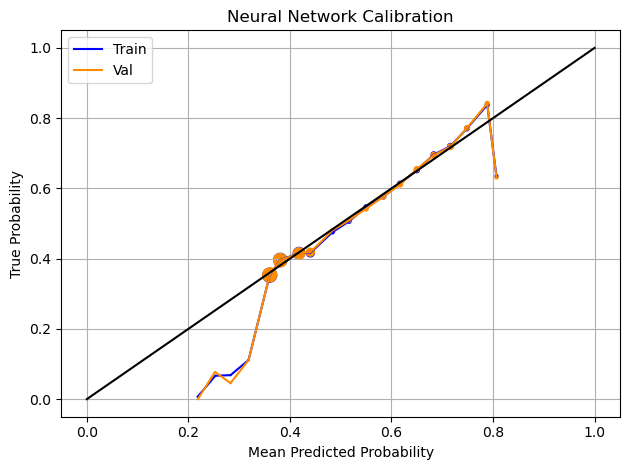

In [22]:
train_probs = best_model.predict_proba(X_train_t).reshape(-1,)
val_probs = best_model.predict_proba(X_val_t).reshape(-1,)
plot_cali_curve(y_train, train_probs, "Train", "blue")
plot_cali_curve(y_val, val_probs, "Val", "darkorange")
plt.title("Neural Network Calibration")
plt.ylabel("True Probability")
plt.xlabel("Mean Predicted Probability")
plt.legend(["Train", "Val"], loc="upper left")
plt.plot([0, 1], [0, 1], color='black')
plt.grid(True)
plt.tight_layout()

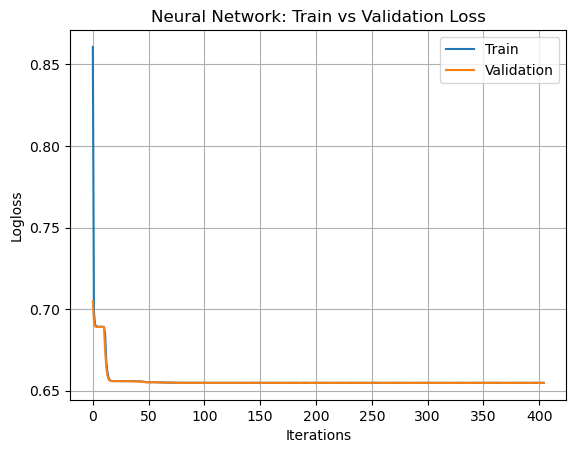

In [23]:
fig, ax = plt.subplots()
ax.plot(train_loss_list, label='Train')
ax.plot(val_loss_list, label='Validation')
ax.set_xlabel('Iterations')
ax.set_ylabel('Logloss')
ax.set_title('Neural Network: Train vs Validation Loss')
ax.legend()
ax.grid(True)

In [24]:
X_full_mm_nn = np.concatenate((X_train_mm, X_val_mm))
y_full = np.concatenate((y_train, y_val))
X_full_t, _, full_loader = create_tensor_dataset(X_full_mm_nn, y_full)

best_nn = MonotonicMLP(**best_params).to(device)
train_loss, query_loss, best_nn, _ = train_model(best_nn, full_loader, lr=best_lr, epochs=best_epoch, validate=False)

In [25]:
X_query_t, _, _ = create_tensor_dataset(X_query_mm, y_query)
X_test_t, _, _ = create_tensor_dataset(X_test_mm, y_test)

score_model(best_nn, X_query_t, y_query, 'nn')
score_model(best_nn, X_test_t, y_test, 'nn')

Log Loss: 0.6549, AUC: 0.6341, Accuracy: 0.6253
Log Loss: 0.6548, AUC: 0.6335, Accuracy: 0.6255
